In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


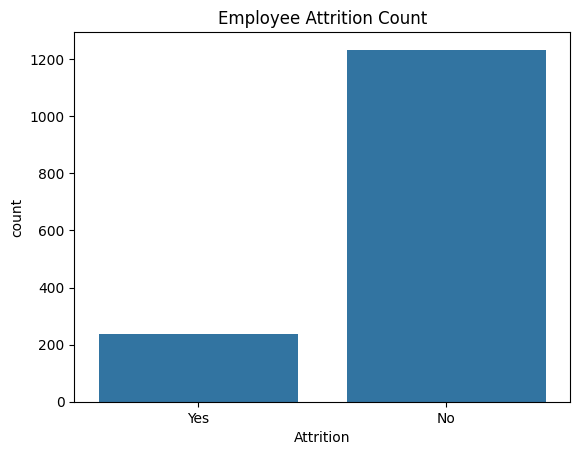

In [8]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

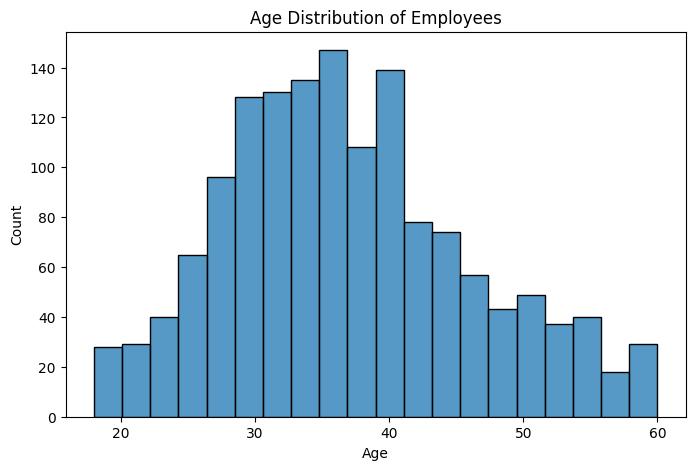

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution of Employees")
plt.show()

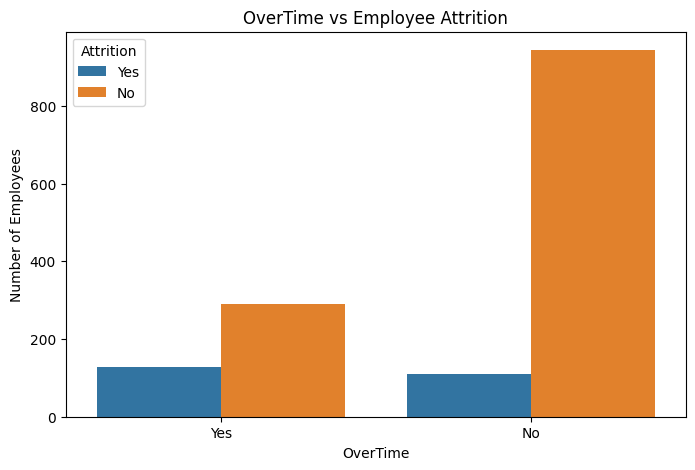

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("OverTime vs Employee Attrition")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

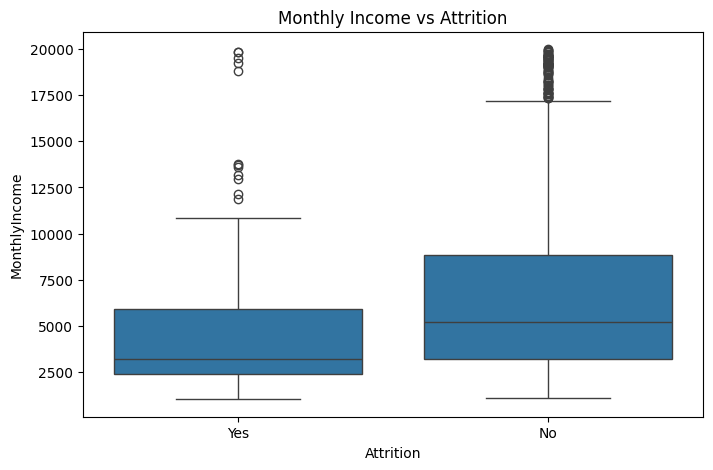

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

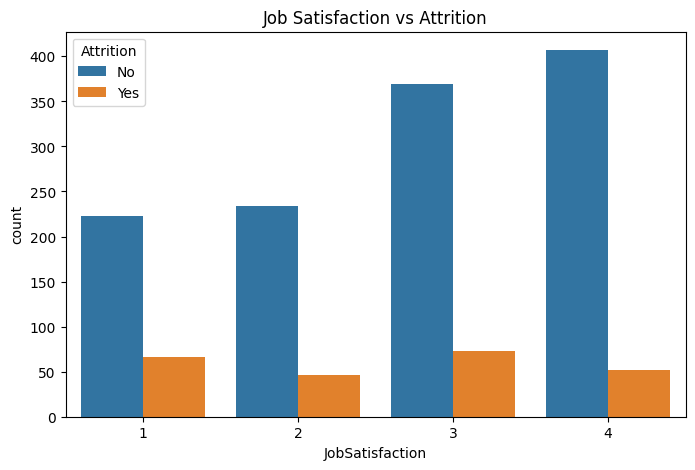

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

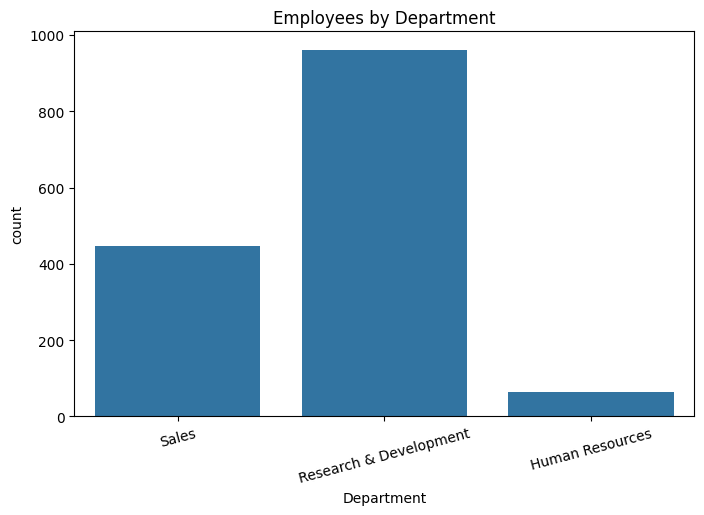

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', data=df)
plt.title("Employees by Department")
plt.xticks(rotation=15)
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [16]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1176, 34)
(294, 34)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8673469387755102


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[251   4]
 [ 35   4]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



In [23]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,MonthlyIncome,0.074968
21,OverTime,0.064823
0,Age,0.056865
2,DailyRate,0.050505
27,TotalWorkingYears,0.048104
18,MonthlyRate,0.047090
8,EmployeeNumber,0.045296
11,HourlyRate,0.043352
4,DistanceFromHome,0.042012
30,YearsAtCompany,0.041914


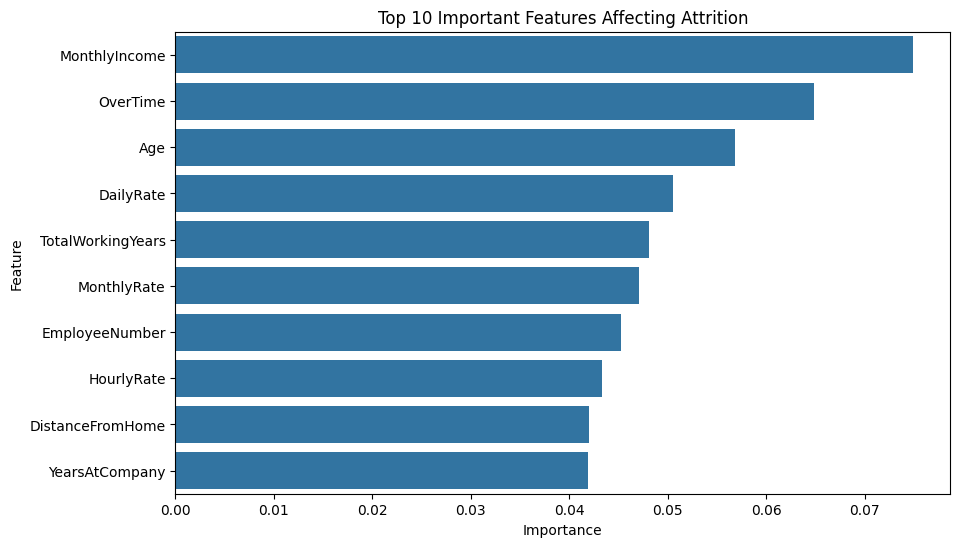

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features Affecting Attrition")
plt.show()

In [25]:
top_features = [
    'Age',
    'MonthlyIncome',
    'OverTime',
    'DistanceFromHome',
    'TotalWorkingYears',
    'YearsAtCompany'
]

X_small = df[top_features]
y_small = df['Attrition']

X_small.head()

,Age,MonthlyIncome,OverTime,DistanceFromHome,TotalWorkingYears,YearsAtCompany
0,41,5993,1,1,8,6
1,49,5130,0,8,10,10
2,37,2090,1,2,7,0
3,33,2909,1,3,8,8
4,27,3468,0,2,6,2


In [26]:
df['OverTime'].head()

,OverTime
0,1
1,0
2,1
3,1
4,0


In [27]:
top_features = [
    'Age',
    'MonthlyIncome',
    'OverTime',
    'DistanceFromHome',
    'TotalWorkingYears',
    'YearsAtCompany'
]

X_small = df[top_features]
y_small = df['Attrition']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

small_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

small_model.fit(X_train, y_train)

pred = small_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8367346938775511


In [28]:
import pickle

with open("attrition_dashboard_model.pkl", "wb") as file:
    pickle.dump(small_model, file)

print("Model Saved Successfully!")

Model Saved Successfully!
